# XGBoost

Этот ноутбук предназначен для построения моделей XGboost (baseline + подбор гиперпараметров при помощи optuna).

In [1]:
# Стандартные библиотеки
import sys
import json
import warnings
from pathlib import Path

# Научные и аналитические библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Специфичные функции и классы
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# Модели и метрики
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
from sklearn.utils import resample

# XGBoost и Optuna
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler

# Сохранение моделей и утилиты
import joblib

# Отключение предупреждений
warnings.filterwarnings('ignore')

In [2]:
# путь до корня проекта
PROJECT_ROOT = Path("../../").resolve()

# добавляем в PYTHONPATH
sys.path.append(str(PROJECT_ROOT))

# теперь обычный импорт
from src.utils.spec_converter import create_feature_spec_template
from src.utils.io import load_feature_names_from_txt

In [3]:
# Пути относительно папки notebooks/group_4/
DATA_PATH = Path("../../data/raw/final_dataset_from_notebooks.csv")
ORIGIN_PATH = Path("../../data/raw/MIPT_hackathon_dataset.csv")
OUTPUT_DIR = Path("../../notebook_outputs/group_4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# seed
SEED = 42

In [5]:
df = pd.read_csv(DATA_PATH)
origin = pd.read_csv(ORIGIN_PATH)

my_full_copy = df.copy()

print("Shape:", my_full_copy.shape)
display(my_full_copy.head())

Shape: (18887, 119)


,row_id,contact_pvz_code,lead_weight_gm,lead_responsible_user_id,lead_utm_content,contact_LTV,sale_date,lead_utm_group,lead_utm_referrer,lead_tags,...,utm_sky_sleep,lead_group_missing,lead_group_grouped,problem_missing,problem_grouped,lead_height_known,lead_height_log,lead_height_bin,delivery_cost_missing,delivery_cost_log
0,0,unknown,-1.0,MGR_0001,116543546_5520577031_16700367732_type1_mobile_...,2920.0,2025-03-01,yur,sleep,tilda,...,0,0,yur,0,Зрительная система,0,0.0,unknown,1,-1.0
1,1,MSK,-1.0,MGR_0002,116057578_5515271477_16779908314_type1_mobile_...,15701.0,2025-03-01,yur,unknown,npotpz,...,0,0,yur,0,Головные боли,0,0.0,unknown,1,-1.0
2,2,unknown,-1.0,MGR_0001,115509254_5508305475_16624953471_type1_mobile_...,13200.0,2025-03-01,yur,unknown,npotpz,...,0,0,yur,0,Варикоз,0,0.0,unknown,1,-1.0
3,3,HOME,-1.0,MGR_0002,unknown,15475.0,2025-03-01,unknown,unknown,artraid,...,0,1,other,0,Суставы и позвоночник,0,0.0,unknown,1,-1.0
4,4,unknown,-1.0,MGR_0001,114252495_5492374363_16498717408_type1_desktop...,12825.0,2025-03-01,yur,unknown,Callibri,...,0,0,yur,0,Суставы и позвоночник,0,0.0,unknown,1,-1.0


In [6]:
# contact_id для разбиения на train/val/test
my_full_copy = pd.merge(my_full_copy,
                        origin[['row_id','contact_id']],
                        on='row_id',
                        how = 'left')

In [7]:
def df_info(df, df_name=None):
    """
    Выводит информацию о датафрейме.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null.sort_values(ascending=False))
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [8]:
df_info(my_full_copy, df_name="Датасет")

----------  Информация о датафрейме Датасет:   ----------

1) Количество строк: 18887
2) Количество столбцов: 120
3) Типы данных:

row_id                        int64
contact_pvz_code                str
lead_weight_gm              float64
lead_responsible_user_id        str
lead_utm_content                str
                             ...   
lead_height_log             float64
lead_height_bin                 str
delivery_cost_missing         int64
delivery_cost_log           float64
contact_id                      str
Length: 120, dtype: object

4) Доля пропусков в каждом из столбцов:

buyout_flag                   4.876370
buyout_flag_lag60             0.317679
buyout_flag_lag30             0.158839
contact_id                    0.026473
sale_dayofweek                0.000000
                                ...   
lead_creation_date_quarter    0.000000
lead_creation_date_month      0.000000
lead_creation_date_week       0.000000
lead_has_creation_date        0.000000
lead_has_linea

In [9]:
cols_to_drop = []

# Пропуски в buyout_flag

In [10]:
buyout_analysis = my_full_copy.copy()

buyout_analysis['flag_is_missing'] = buyout_analysis['buyout_flag'].isna().astype(int)

buyout_analysis.groupby('flag_is_missing')['timedelta_between_sale_and_creation'].describe()

,count,mean,std,min,25%,50%,75%,max
flag_is_missing,,,,,,,,
0,17966.0,390226.606089,2.585009e+06,25.0,1584.0,3250.5,14876.25,59429439.0
1,921.0,204443.022801,1.797492e+06,534.0,2261.0,3673.0,10410.00,32553653.0


Пропуски не сконцентрированы на дорогих заказах. Среднее в группе с пропусками почти в два раза ниже, чем в группе без пропусков. Медианы практически идентичны.

Это говорит о том, что в группе без пропусков есть выбросы-гиганты (до 59 млн), которые тянут среднее вверх. В группе с пропусками таких экстремальных выбросов меньше.

In [11]:
print("--Время с момента заказа--")
display(buyout_analysis.groupby('flag_is_missing')['timedelta_between_sale_and_creation'].describe())

--Время с момента заказа--


,count,mean,std,min,25%,50%,75%,max
flag_is_missing,,,,,,,,
0,17966.0,390226.606089,2.585009e+06,25.0,1584.0,3250.5,14876.25,59429439.0
1,921.0,204443.022801,1.797492e+06,534.0,2261.0,3673.0,10410.00,32553653.0


In [12]:
print("--Доля пропусков по квалификации лида--")
display(buyout_analysis.groupby('lead_Квалификация лида')['flag_is_missing'].mean().sort_values(ascending=False))

--Доля пропусков по квалификации лида--


lead_Квалификация лида
Е - лид       0.250000
В - лид       0.090883
С - лид       0.077850
А - лид       0.065918
Неквал лид    0.022346
unknown       0.001067
D - лид       0.000000
Name: flag_is_missing, dtype: float64

Пропуски системны и зависят от класса лида
Е-лиды — это, скорее всего, самый свежий или необработанный сегмент (возможно, только что поступившие заявки, по которым еще не завершен цикл сделки).
Неквал лид и D-лид — это закрытые/отработанные категории, где статус уже определен.
Удалять строки нельзя. Мы потеряем 25% заказов из категории "Е", что полностью исказит представление модели о воронке продаж.

In [13]:
# Добавляем признак "возраст заказа в днях"
max_date = pd.to_datetime(buyout_analysis['sale_date']).max()

buyout_analysis['order_age_days'] = (max_date - pd.to_datetime(buyout_analysis['sale_date'])).dt.days

# Разбиваем на старые (>30 дней) и свежие (<=7 дней)
buyout_analysis['age_group'] = pd.cut(buyout_analysis['order_age_days'], 
                                   bins=[0, 7, 30, float('inf')], 
                                   labels=['fresh', 'medium', 'old'])

# Смотрим распределение квалификации по возрастным группам
print("Распределение квалификации по возрастным группам")
cross_tab = pd.crosstab(buyout_analysis['age_group'], buyout_analysis['lead_Квалификация лида'], normalize='index')
print((cross_tab * 100).round(2))

Распределение квалификации по возрастным группам
lead_Квалификация лида  D - лид  unknown  А - лид  В - лид  Е - лид  \
age_group                                                             
fresh                      0.00     0.00    50.94    30.02     0.00   
medium                     0.12     0.29    52.46    30.76     0.23   
old                        0.11    39.67    32.99    16.48     0.00   

lead_Квалификация лида  Неквал лид  С - лид  
age_group                                    
fresh                         0.51    18.52  
medium                        0.29    15.85  
old                           1.03     9.71  


In [14]:
e_lead_by_age = buyout_analysis.groupby('age_group').apply(
    lambda x: (x['lead_Квалификация лида'] == 'Е - лид').mean()
)
print("--Доля E-лидов по возрасту заказа--")
display(e_lead_by_age)

--Доля E-лидов по возрасту заказа--


age_group
fresh     0.000000
medium    0.002339
old       0.000000
dtype: float64

**Решение**: Е-лиды исчезают в старых заказах и отсутствуют в новых. При этом в группе medium их больше всего. Е-лид - это временный статус, который присваивается новым заказам. В старых заказах Е-лидов почти нет (статус уже снят), и пропусков в `buyout_flag` тоже нет (флаг уже проставлен).

Таким образом, строки с пропусками в `buyout_flag` удаляем. `lead_Квалификация лида` == 'Е - лид' также является утечкой, поэтому этот признак из прогнозирования исключим.

# Преобразование contact_loyalty

В ходе анализа было выявлено, что `contact_loyalty` был рассчитан на основе признака `contact_Число сделок`, который содержит информацию о будущих заказах, что является утечкой.
Ошибочный признак удалим и заменим на новый (количество сделок будет учитывать только текущий и предыдущий заказы на момент `sale_ts`)

In [15]:
my_full_copy = my_full_copy.drop(columns=['contact_loyalty','lead_Квалификация лида'])

In [16]:
def create_features_for_join(df_original):
    """
    Рассчитывает contact_loaylty только на основании
    текущей и прошлых сделок
    """
    df = df_original.copy()
    df = df.sort_values(['contact_id', 'sale_ts'])
    
    new_features = pd.DataFrame({
        'row_id': df['row_id'],
        'prev_orders_count': df.groupby('contact_id').cumcount(),
    })
    
    new_features['contact_loyalty'] = new_features['prev_orders_count'].apply(
        lambda x: 'new' if x == 0 else ('regular' if x <= 2 else ('loyal' if x <= 5 else 'vip'))
    )
    
    return new_features

In [17]:
# Создаем отдельный датафрейм
new_features_df = create_features_for_join(origin)

# Присоединяем к основному датафрейму
my_full_copy = my_full_copy.merge(new_features_df, on='row_id', how='inner')

# Проверка признаков через CatBoost

Поскольку датасет содержит большое количество признаков, а при их кодировании количество вырастет дополнительно, проведем отбор признаков через CatBoost, оставив только топ-20 по важности.

In [18]:
# Подготовка данных
df_model = my_full_copy[my_full_copy['buyout_flag'].notna()].copy()
df_model = df_model.drop(columns='contact_id')
df_model['target'] = df_model['buyout_flag'].astype(int)

# Определяем категориальные признаки
categorical_cols = df_model.select_dtypes(include=['str', 'category']).columns.tolist()

In [19]:
# Разделяем на train/test
X_cb = df_model[categorical_cols]
y_cb = df_model['target']

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X_cb, y_cb, test_size=0.2, random_state=SEED, stratify=y_cb)

In [20]:
# Обучаем CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100,
    cat_features=categorical_cols,
    early_stopping_rounds=50
)

model.fit(
    X_train_cb, y_train_cb,
    eval_set=(X_test_cb, y_test_cb),
    plot=False
)

0:	test: 0.5998381	best: 0.5998381 (0)	total: 89.9ms	remaining: 44.9s
100:	test: 0.6626179	best: 0.6626734 (97)	total: 2.29s	remaining: 9.03s
200:	test: 0.6682369	best: 0.6682597 (199)	total: 4.59s	remaining: 6.83s
300:	test: 0.6696055	best: 0.6698691 (291)	total: 6.96s	remaining: 4.61s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6709505452
bestIteration = 320

Shrink model to first 321 iterations.


CatBoostClassifier(cat_features=['contact_pvz_code', 'lead_responsible_user_id', 'lead_utm_content', 'sale_date', 'lead_utm_group', 'lead_utm_referrer', 'lead_tags', 'lead_utm_source', 'contact_region_pvz', 'lead_utm_referrer_site', 'lead_utm_device_type', 'lead_utm_site', 'lead_utm_region_name', 'contact_Город', 'contact_region', 'lead_manager_category', 'lead_discount_category', 'sale_ts', 'lead_source', 'lead_created_ts', 'width_cat', 'lead_payment_type', 'lead_delivery_type', 'lead_utm_campaign_grouped', 'traffic_source_grouped', 'utm_term_grouped', 'lead_group_grouped', 'problem_grouped', 'lead_height_bin', 'contact_loyalty'], depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [21]:
# Получаем важность признаков
importance = pd.DataFrame({
    'feature': categorical_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("--Признаки по убыванию важности--")
print(importance.to_string(index=False))

--Признаки по убыванию важности--
                  feature  importance
                width_cat    8.589104
                sale_date    7.572603
       lead_delivery_type    7.264331
        lead_payment_type    7.222345
          lead_height_bin    6.864336
     lead_utm_device_type    6.657817
           lead_utm_group    5.761455
                lead_tags    5.559955
 lead_responsible_user_id    4.735101
          contact_loyalty    4.303674
         utm_term_grouped    3.316368
            lead_utm_site    3.010311
        lead_utm_referrer    3.006765
              lead_source    2.958465
         contact_pvz_code    2.631175
lead_utm_campaign_grouped    2.357206
          problem_grouped    2.348950
       contact_region_pvz    2.270048
          lead_utm_source    2.183486
   lead_discount_category    2.075707
   lead_utm_referrer_site    1.957022
       lead_group_grouped    1.653627
           contact_region    1.313225
     lead_utm_region_name    1.238733
    lead_manager

Далее для прогнозирования оставим только топ-20 признаков по важности (покрывают примерно 85% накопленной важности). Вместо `sale_date`  будем использовать производные признаки.

# Сборка итогового датасета

In [22]:
# Формируем итоговый набор
final_features = list(importance['feature'].head(20).values)

final_features.remove('sale_date')

addiational_cols = [
    'sale_month',
    'sale_dayofweek',
    'sale_quarter',
    'sale_date_sin',
    'sale_date_cos',
    'contact_id', # Для разбиения
    'buyout_flag'# Таргет
]

for feat in addiational_cols:
    if feat in my_full_copy.columns and feat not in final_features:
        final_features.append(feat) 

print(f"Итоговое количество: {len(final_features)}")
print(f"Список: {final_features}")

Итоговое количество: 25
Список: ['width_cat', 'lead_delivery_type', 'lead_payment_type', 'lead_height_bin', 'lead_utm_device_type', 'lead_utm_group', 'lead_tags', 'lead_responsible_user_id', 'contact_loyalty', 'utm_term_grouped', 'lead_utm_site', 'lead_utm_referrer', 'lead_source', 'contact_pvz_code', 'lead_utm_campaign_grouped', 'problem_grouped', 'contact_region_pvz', 'lead_utm_source', 'lead_discount_category', 'sale_month', 'sale_dayofweek', 'sale_date_sin', 'sale_date_cos', 'contact_id', 'buyout_flag']


In [23]:
selected_df = my_full_copy[final_features].copy()

In [24]:
df_info(selected_df,'Датафрейм с отобранными признаками')

----------  Информация о датафрейме Датафрейм с отобранными признаками:   ----------

1) Количество строк: 18887
2) Количество столбцов: 25
3) Типы данных:

width_cat                        str
lead_delivery_type               str
lead_payment_type                str
lead_height_bin                  str
lead_utm_device_type             str
lead_utm_group                   str
lead_tags                        str
lead_responsible_user_id         str
contact_loyalty                  str
utm_term_grouped                 str
lead_utm_site                    str
lead_utm_referrer                str
lead_source                      str
contact_pvz_code                 str
lead_utm_campaign_grouped        str
problem_grouped                  str
contact_region_pvz               str
lead_utm_source                  str
lead_discount_category           str
sale_month                     int64
sale_dayofweek                 int64
sale_date_sin                float64
sale_date_cos                

In [25]:
selected_df = selected_df.drop_duplicates()
print(f"Размер после удаления дубликатов: {selected_df.shape}")

Размер после удаления дубликатов: (18885, 25)


In [26]:
# Убираем пропуски
selected_df = selected_df[selected_df['buyout_flag'].notna()]

# Преобразуем к бинарным значениям
selected_df['buyout_flag'] = selected_df['buyout_flag'].astype(int)

In [27]:
selected_df['buyout_flag'].value_counts(normalize=True)

buyout_flag
1    0.828333
0    0.171667
Name: proportion, dtype: float64

В данных есть ярковыраженая несбалансированность классов. Отказы составляют всего лишь 17% данных. Таким образом, при построении модели могут возникнуть сложности с определением отказов.

interval columns not set, guessing: ['sale_month', 'sale_dayofweek', 'sale_date_sin', 'sale_date_cos', 'buyout_flag']


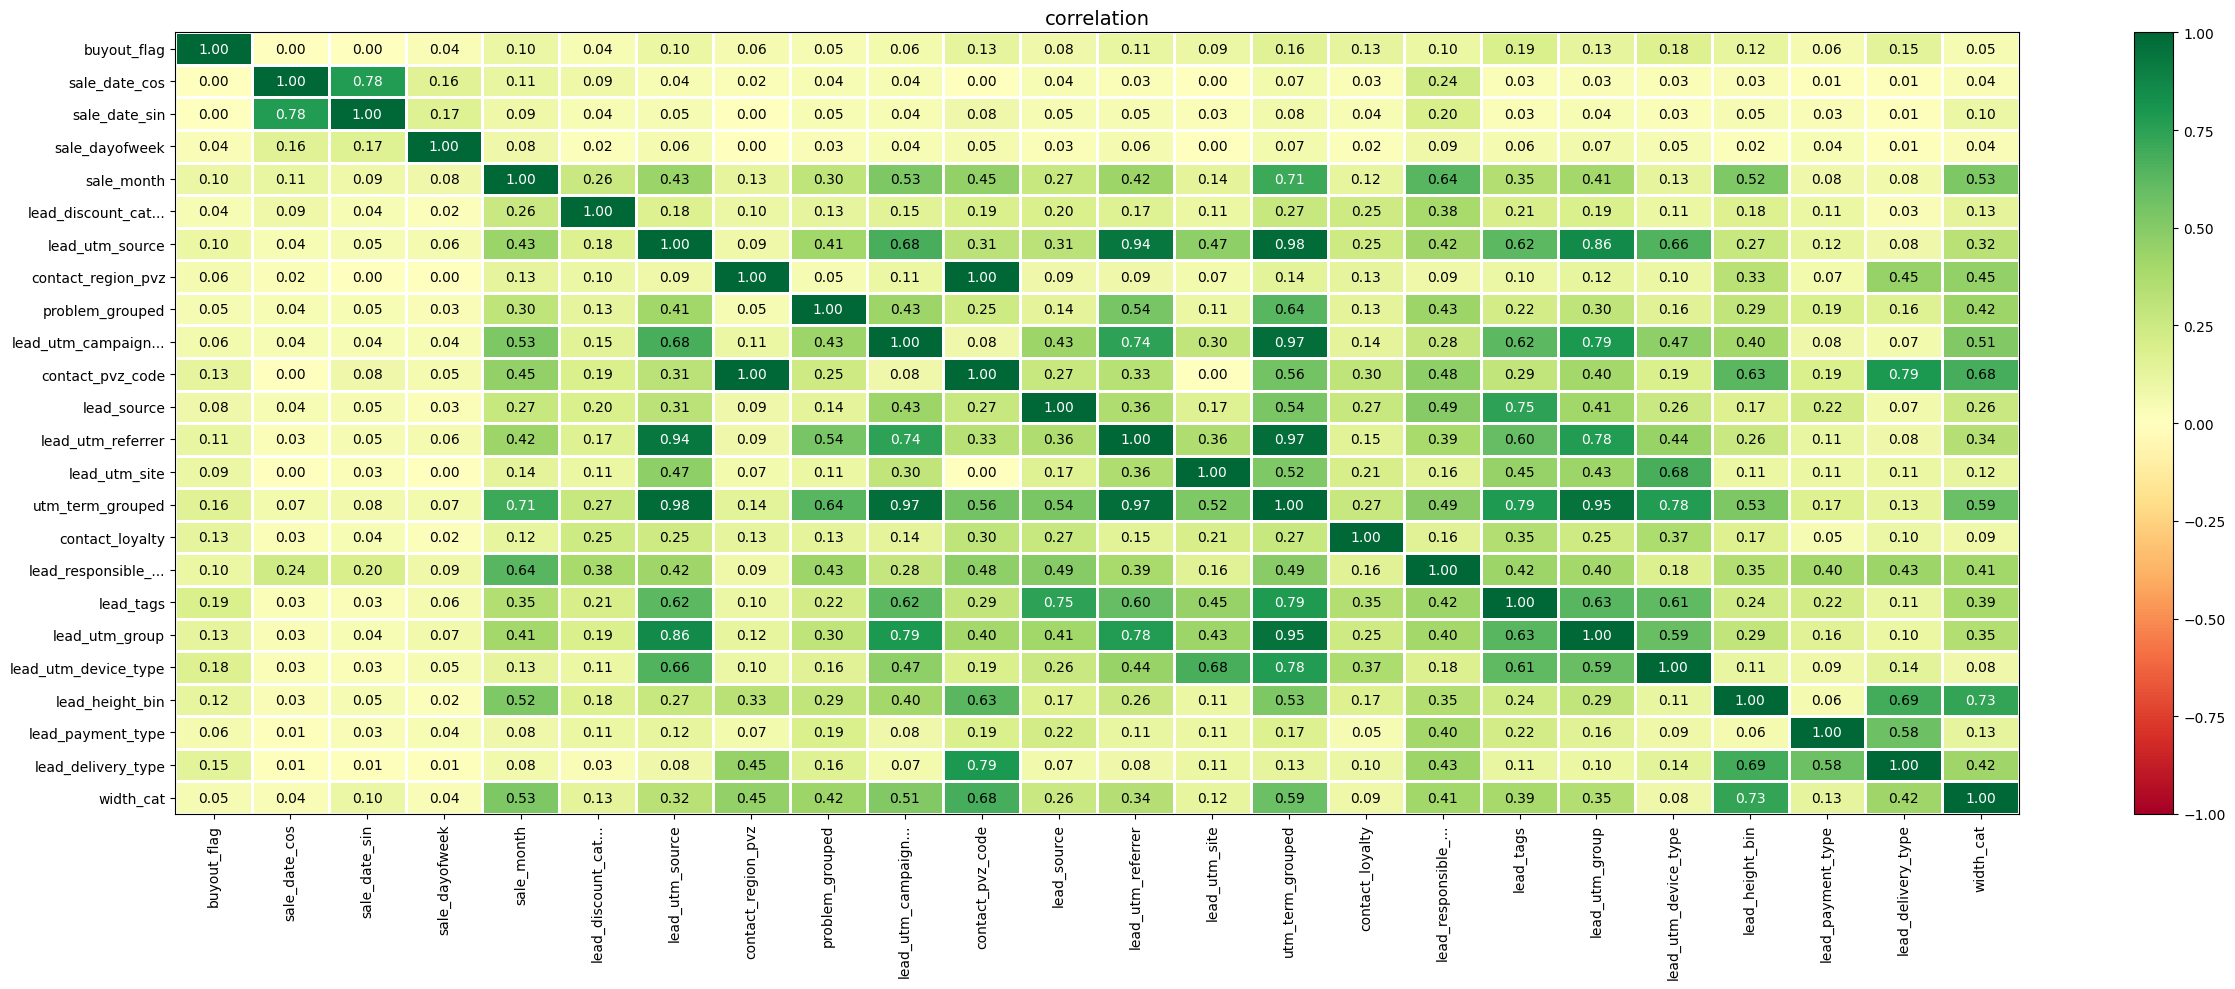

In [28]:
# Проверяем мультиколлинеарность
df_for_phik = selected_df.copy()

corr_matrix = phik_matrix(df_for_phik.drop(columns=[
    'contact_id'
]))

plot_correlation_matrix(corr_matrix.values,
                        x_labels=corr_matrix.columns,
                        y_labels=corr_matrix.index,
                        figsize=(25, 10))

В данных есть мультиколлинеарные признаки, поэтому при подборе гиперпараметров через Optuna важно учесть необходимость применения регуляризации.

Для разбиения на обучающую, валидационную и тестовую выборки воспользуемся методом bootstrap-разбиения по клиентам.

Таким образом, все заказы одного клиента (`contact_id`) должны попадать только в одну выборку (`train`, `val` или `test`). Это предотвращает утечку данных, так как поведение одного клиента (например, история его заказов, лояльность) может быть скоррелировано.

In [29]:
def bootstrap_split_cv(df, customer_col='contact_id', 
                       val_size=0.15, test_size=0.15, 
                       n_splits=5, random_state=SEED):
    """
    Bootstrap разбиение данных с train/val/test по клиентам
    """
    unique_customers = df[customer_col].unique()
    n_customers = len(unique_customers)
    
    n_test = int(n_customers * test_size)
    n_val = int(n_customers * val_size)
    n_train = n_customers - n_test - n_val
    
    print(f"Всего клиентов: {n_customers}")
    print(f"Train: {n_train} клиентов ({n_train/n_customers:.1%})")
    print(f"Val: {n_val} клиентов ({n_val/n_customers:.1%})")
    print(f"Test: {n_test} клиентов ({n_test/n_customers:.1%})")
    print("-"*50)
    
    splits = []
    for split_id in range(n_splits):
        shuffled = resample(unique_customers, replace=False,
                            n_samples=n_customers, random_state=random_state + split_id)
        test_cust = set(shuffled[:n_test])
        val_cust = set(shuffled[n_test:n_test + n_val])
        train_cust = set(shuffled[n_test + n_val:])
        
        splits.append({
            'split_id': split_id,
            'train_idx': df[df[customer_col].isin(train_cust)].index,
            'val_idx': df[df[customer_col].isin(val_cust)].index,
            'test_idx': df[df[customer_col].isin(test_cust)].index,
        })
        print(f"Сплит {split_id+1}: Train={len(splits[-1]['train_idx'])} | "
              f"Val={len(splits[-1]['val_idx'])} | Test={len(splits[-1]['test_idx'])}")
    return splits

In [30]:
split = bootstrap_split_cv(selected_df, customer_col='contact_id')

Всего клиентов: 15489
Train: 10843 клиентов (70.0%)
Val: 2323 клиентов (15.0%)
Test: 2323 клиентов (15.0%)
--------------------------------------------------
Сплит 1: Train=12586 | Val=2670 | Test=2709
Сплит 2: Train=12551 | Val=2673 | Test=2741
Сплит 3: Train=12601 | Val=2686 | Test=2678
Сплит 4: Train=12644 | Val=2627 | Test=2694
Сплит 5: Train=12586 | Val=2699 | Test=2680


Получено 5 непересекающихся разбиений, каждое из которых содержит индексы строк для train, val и test. Это позволило в дальнейшем провести корректную кросс-валидацию и обучить финальную модель на всех доступных данных (train+val) без риска утечки.

Так как будем использовать XGBoost нормализация не потребуется.
Но потребуется закодировать категориальные признаки.

In [31]:
def prepare_split_data(split, selected_df):
    """
    Кодирование категориальных признаков (OneHot, Ordinal, Label, Frequency)
    Возвращает X_train_enc, X_val_enc, X_test_enc, y_train, y_val, y_test
    """
    onehot_cols = ['width_cat', 'lead_height_bin', 'lead_delivery_type', 
                   'lead_payment_type', 'lead_utm_device_type']
    
    ordinal_cols = {'contact_loyalty': ['new', 'regular', 'loyal', 'vip']}
    
    frequency_cols = ['lead_utm_group', 'lead_utm_source', 'lead_responsible_user_id', 
                      'contact_pvz_code', 'utm_term_grouped', 'lead_utm_site',
                      'lead_utm_referrer', 'lead_utm_campaign_grouped', 
                      'contact_region_pvz', 'problem_grouped']
    
    label_cols = ['lead_tags', 'lead_source', 'lead_discount_category']
    
    exclude_cols = ['buyout_flag', 'sale_ts', 'contact_id', 'row_id']
    feature_cols = [c for c in selected_df.columns if c not in exclude_cols]
    
    X_train = selected_df.loc[split['train_idx'], feature_cols].copy()
    y_train = selected_df.loc[split['train_idx'], 'buyout_flag']
    X_val = selected_df.loc[split['val_idx'], feature_cols].copy() if len(split['val_idx']) else pd.DataFrame()
    y_val = selected_df.loc[split['val_idx'], 'buyout_flag'] if len(split['val_idx']) else pd.Series(dtype='float64')
    X_test = selected_df.loc[split['test_idx'], feature_cols].copy()
    y_test = selected_df.loc[split['test_idx'], 'buyout_flag']
    
    # One‑Hot
    ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    ohe.fit(X_train[onehot_cols].astype(str))
    train_ohe = ohe.transform(X_train[onehot_cols].astype(str))
    test_ohe = ohe.transform(X_test[onehot_cols].astype(str))
    ohe_cols = ohe.get_feature_names_out(onehot_cols)
    X_train_enc = pd.concat([X_train.drop(columns=onehot_cols), 
                             pd.DataFrame(train_ohe, columns=ohe_cols, index=X_train.index)], axis=1)
    X_test_enc = pd.concat([X_test.drop(columns=onehot_cols), 
                            pd.DataFrame(test_ohe, columns=ohe_cols, index=X_test.index)], axis=1)
    if len(X_val):
        val_ohe = ohe.transform(X_val[onehot_cols].astype(str))
        X_val_enc = pd.concat([X_val.drop(columns=onehot_cols), 
                               pd.DataFrame(val_ohe, columns=ohe_cols, index=X_val.index)], axis=1)
    else:
        X_val_enc = pd.DataFrame()
    
    # Ordinal
    for col, order in ordinal_cols.items():
        if col in X_train_enc.columns:
            oe = OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
            X_train_enc[col+'_ord'] = oe.fit_transform(X_train_enc[[col]].astype(str))
            X_test_enc[col+'_ord'] = oe.transform(X_test_enc[[col]].astype(str))
            X_train_enc.drop(columns=[col], inplace=True)
            X_test_enc.drop(columns=[col], inplace=True)
            if len(X_val_enc) and col in X_val_enc.columns:
                X_val_enc[col+'_ord'] = oe.transform(X_val_enc[[col]].astype(str))
                X_val_enc.drop(columns=[col], inplace=True)
    
    # Label
    for col in label_cols:
        if col in X_train_enc.columns:
            le = LabelEncoder()
            le.fit(X_train_enc[col].astype(str))
            X_train_enc[col+'_lbl'] = le.transform(X_train_enc[col].astype(str))
            X_test_enc[col+'_lbl'] = le.transform(X_test_enc[col].astype(str))
            X_train_enc.drop(columns=[col], inplace=True)
            X_test_enc.drop(columns=[col], inplace=True)
            if len(X_val_enc) and col in X_val_enc.columns:
                X_val_enc[col+'_lbl'] = le.transform(X_val_enc[col].astype(str))
                X_val_enc.drop(columns=[col], inplace=True)
    
    # Frequency
    for col in frequency_cols:
        if col in X_train_enc.columns:
            freq = X_train_enc[col].value_counts(normalize=True)
            X_train_enc[col+'_freq'] = X_train_enc[col].map(freq).fillna(0)
            X_test_enc[col+'_freq'] = X_test_enc[col].map(freq).fillna(0)
            X_train_enc.drop(columns=[col], inplace=True)
            X_test_enc.drop(columns=[col], inplace=True)
            if len(X_val_enc) and col in X_val_enc.columns:
                X_val_enc[col+'_freq'] = X_val_enc[col].map(freq).fillna(0)
                X_val_enc.drop(columns=[col], inplace=True)
    
    return X_train_enc, X_val_enc, X_test_enc, y_train, y_val, y_test

# Обучение XGBoost

XGBoost выбран как один из лучших алгоритмов для табличных данных с дисбалансом классов. Он устойчив к выбросам, поддерживает регуляризацию и позволяет задавать веса классов (через scale_pos_weight).

В качестве основной метрики выберем PR-AUC (Average Precision). В условиях несбалансированности классов ROC-AUC может быть давать завышенное значение, а PR-AUC лучше отражает способность модели находить редкий класс. Мы также рассчитывали PR-AUC для класса 0, чтобы оценить качество предсказания невыкупов.

In [32]:
def cross_validate_splits(splits, selected_df, params=None):
    if params is None:
        params = {
            'n_estimators': 100,
            'max_depth': 4,
            'learning_rate': 0.05,
            'random_state': SEED,
            'eval_metric': 'auc',
            'use_label_encoder': False,
            'verbosity': 0
        }
        
    results = []
    
    for split in splits:
        X_tr, X_val, X_te, y_tr, y_val, y_te = prepare_split_data(split, selected_df)
        scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()
        p = params.copy()
        p['scale_pos_weight'] = scale_pos
        model = xgb.XGBClassifier(**p)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict_proba(X_te)[:, 1]
        results.append({
            'split_id': split['split_id'],
            'pr_auc_1': average_precision_score(y_te, y_pred),
            'pr_auc_0': average_precision_score(1-y_te, 1-y_pred),
            'roc_auc': roc_auc_score(y_te, y_pred),
        })
        print(f"Сплит {split['split_id']+1}: PR-AUC(1)={results[-1]['pr_auc_1']:.4f}, "
              f"PR-AUC(0)={results[-1]['pr_auc_0']:.4f}, ROC={results[-1]['roc_auc']:.4f}")
        
    print("--- Результаты кросс-валидации ---")
    print(f"PR-AUC(1): {np.mean([r['pr_auc_1'] for r in results]):.4f} ± {np.std([r['pr_auc_1'] for r in results]):.4f}")
    print(f"PR-AUC(0): {np.mean([r['pr_auc_0'] for r in results]):.4f} ± {np.std([r['pr_auc_0'] for r in results]):.4f}")
    print(f"ROC-AUC:   {np.mean([r['roc_auc'] for r in results]):.4f} ± {np.std([r['roc_auc'] for r in results]):.4f}")
    print()
    return results

In [33]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import average_precision_score

def optimize_pr_auc_0(splits, selected_df, n_trials=30):
    """
    Оптимизация гиперпараметров XGBoost для максимизации PR-AUC класса 0 (невыкуп).
    """
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 3),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.1, 1.0, log=True),
            'random_state': SEED,
            'eval_metric': 'auc',
            'use_label_encoder': False,
            'verbosity': 0
        }
        
        cv_pr_auc_0 = []
        for split in splits:
            X_tr, X_val, _, y_tr, y_val, _ = prepare_split_data(split, selected_df)
            if len(X_val) == 0:
                continue
            model = xgb.XGBClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            y_pred = model.predict_proba(X_val)[:, 1]          # вероятность класса 1
            y_pred_0 = 1 - y_pred                              # вероятность класса 0
            pr_auc_0 = average_precision_score(1 - y_val, y_pred_0)
            cv_pr_auc_0.append(pr_auc_0)
        
        return np.mean(cv_pr_auc_0)
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print("--- Результат оптимизации Optuna (PR-AUC по классу 0) ---")
    print(f"Лучший PR-AUC(0) на val: {study.best_value:.4f}")
    print(f"Лучшие параметры: {study.best_params}")
    print()
    return study

In [34]:
def train_final_model(splits, selected_df, params=None, threshold=0.5):
    if params is None:
        params = {
            'n_estimators': 200,
            'max_depth': 4,
            'learning_rate': 0.05,
            'random_state': SEED,
            'eval_metric': 'auc',
            'use_label_encoder': False,
            'verbosity': 0
        }
    # Собираем все индексы
    all_train_idx = []
    all_val_idx = []
    for split in splits:
        all_train_idx.extend(split['train_idx'].tolist())
        all_val_idx.extend(split['val_idx'].tolist())
    all_train_idx = list(set(all_train_idx))
    all_val_idx = list(set(all_val_idx))
    overlap = set(all_train_idx) & set(all_val_idx)
    if overlap:
        all_val_idx = list(set(all_val_idx) - overlap)
    all_train_val_idx = all_train_idx + all_val_idx
    all_test_idx = list(set().union(*[s['test_idx'].tolist() for s in splits]))
    
    print(f"Train+Val: {len(all_train_val_idx)} строк, Test: {len(all_test_idx)} строк")
    
    # Фиктивный сплит для кодирования
    dummy_split = {'train_idx': all_train_val_idx, 'val_idx': [], 'test_idx': all_test_idx}
    X_train, _, X_test, y_train, _, y_test = prepare_split_data(dummy_split, selected_df)
    
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    params['scale_pos_weight'] = scale_pos
    print(f"scale_pos_weight = {scale_pos:.3f}")
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_test)[:, 1]
    y_pred_bin = (y_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin).ravel()
    
    metrics = {
        'threshold': threshold,
        'pr_auc_1': average_precision_score(y_test, y_pred),
        'pr_auc_0': average_precision_score(1-y_test, 1-y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred),
        'precision_0': tn/(tn+fn) if (tn+fn) else 0,
        'recall_0': tn/(tn+fp) if (tn+fp) else 0,
        'precision_1': tp/(tp+fp) if (tp+fp) else 0,
        'recall_1': tp/(tp+fn) if (tp+fn) else 0,
    }
    
    print("Финальные метрики")
    print(f"PR-AUC(1): {metrics['pr_auc_1']:.4f}")
    print(f"PR-AUC(0): {metrics['pr_auc_0']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"Precision(1): {metrics['precision_1']:.4f}, Recall(1): {metrics['recall_1']:.4f}")
    print(f"Precision(0): {metrics['precision_0']:.4f}, Recall(0): {metrics['recall_0']:.4f}")
    print()
    return model, metrics

In [35]:
splits = bootstrap_split_cv(selected_df, customer_col='contact_id', n_splits=5, random_state=SEED)

# Кросс-валидация для оценки стабильности
cv_results = cross_validate_splits(splits, selected_df)

final_model, final_metrics = train_final_model(splits, selected_df, threshold=0.5)

Всего клиентов: 15489
Train: 10843 клиентов (70.0%)
Val: 2323 клиентов (15.0%)
Test: 2323 клиентов (15.0%)
--------------------------------------------------
Сплит 1: Train=12586 | Val=2670 | Test=2709
Сплит 2: Train=12551 | Val=2673 | Test=2741
Сплит 3: Train=12601 | Val=2686 | Test=2678
Сплит 4: Train=12644 | Val=2627 | Test=2694
Сплит 5: Train=12586 | Val=2699 | Test=2680
Сплит 1: PR-AUC(1)=0.9118, PR-AUC(0)=0.3161, ROC=0.6808
Сплит 2: PR-AUC(1)=0.9084, PR-AUC(0)=0.3347, ROC=0.6779
Сплит 3: PR-AUC(1)=0.9116, PR-AUC(0)=0.3327, ROC=0.6811
Сплит 4: PR-AUC(1)=0.9148, PR-AUC(0)=0.3150, ROC=0.6788
Сплит 5: PR-AUC(1)=0.9075, PR-AUC(0)=0.3456, ROC=0.6865
--- Результаты кросс-валидации ---
PR-AUC(1): 0.9108 ± 0.0026
PR-AUC(0): 0.3288 ± 0.0117
ROC-AUC:   0.6810 ± 0.0030

Train+Val: 17959 строк, Test: 10065 строк
scale_pos_weight = 0.207
Финальные метрики
PR-AUC(1): 0.9329
PR-AUC(0): 0.4031
ROC-AUC:   0.7467
Precision(1): 0.9190, Recall(1): 0.6117
Precision(0): 0.2847, Recall(0): 0.7414



На этапе кросс валидации модель показывает почти одинаковые результаты на разных случайных разбиениях клиентов. Это гарантирует, что модель не переобучена под конкретный состав выборки.

**PR-AUC (Average Precision)**
- Для выкупов (0.933) – модель почти идеально ранжирует заказы: чем выше вероятность, тем выше шанс, что заказ действительно выкупят.
- Для невыкупов (0.403) – модель лучше случайного угадывания, но не настолько точна, чтобы полагаться на неё для автоматического отклонения заказов.

**Precision и Recall**
- Precision(1) = 92% - можно смело доверять положительным прогнозам. Если модель говорит «выкуп», то в 92% случаев это правда.
- Recall(1) = 61% – при этом модель пропускает 39% реальных выкупов. Это означает, что часть хороших клиентов не будет распознана, но для многих задач этого достаточно.
- Recall(0) = 74% – модель неплохо находит проблемные заказы, но Precision(0) низкая (28%), поэтому будет много ложных тревог (заказы, предсказанные как невыкуп, но на самом деле выкупленные).

Кросс-валидация показала низкие стандартные отклонения, что подтверждает надёжность и обобщающую способность.
Финальные метрики на тесте (0.9329 PR-AUC(1)) немного выше, чем средние по кросс-валидации (0.9108), что говорит об отсутствии переобучения и хорошем соответствии распределения тестовой выборки.

# Optuna
Попробуем улучшить предсказательную способность модели черезе `optuna`.

In [36]:
# Optuna
study_0 = optimize_pr_auc_0(splits, selected_df, n_trials=30)

# Получаем best_params из Optuna
best_params = study_0.best_params

fixed_params = {
    'random_state': SEED,
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'verbosity': 0,
    'tree_method': 'hist',
    'n_jobs': -1,
}

full_params = {**best_params, **fixed_params}

model_optuna, metrics_optuna = train_final_model(
    splits, selected_df, 
    params=full_params,
    threshold=0.5
)

[I 2026-04-11 19:08:28,604] A new study created in memory with name: no-name-8a637078-e8a4-4ed1-937a-2f079ec07d60


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-11 19:08:30,384] Trial 0 finished with value: 0.3274376905822811 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05395030966670229, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309, 'min_child_weight': 2, 'gamma': 0.17425083650459838, 'reg_alpha': 3.9676050770529874, 'reg_lambda': 0.6358358856676253, 'scale_pos_weight': 0.5105903209394755}. Best is trial 0 with value: 0.3274376905822811.
[I 2026-04-11 19:08:31,616] Trial 1 finished with value: 0.3176731841867764 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.06798962421591129, 'subsample': 0.6637017332034828, 'colsample_bytree': 0.6545474901621302, 'min_child_weight': 2, 'gamma': 0.9127267288786132, 'reg_alpha': 0.37520558551242816, 'reg_lambda': 0.19762189340280073, 'scale_pos_weight': 0.1955370866274525}. Best is trial 0 with value: 0.3274376905822811.
[I 2026-04-11 19:08:33,449] Trial 2 finished with value: 0.2982513719784201 and parameters: {'n_esti

Исходная модель остаётся лучшей по ключевым метрикам (PR-AUC(1), PR-AUC(0), ROC-AUC). Прирост Recall(1) на 1% не компенсирует падение других показателей.

In [37]:
# Сохраняем модель
joblib.dump(final_model, '../../model/xgboost_final.pkl')
print("Модель сохранена в '../../model/xgboost_final.pkl'")

# Сохраняем метрики
with open('../../model/final_metrics.json', 'w') as f:
    # Преобразуем numpy типы в стандартные Python
    clean_metrics = {k: float(v) if isinstance(v, (np.float32, np.float64)) else v 
                      for k, v in final_metrics.items()}
    json.dump(clean_metrics, f, indent=2)

print("Метрики сохранены в '../../model/final_metrics.json'")

Модель сохранена в '../../model/xgboost_final.pkl'
Метрики сохранены в '../../model/final_metrics.json'
